# Notebook 1 — Wind Forecast Error Analysis
**Data source:** Elexon BMRS API — FUELHH (actuals) + WINDFOR (forecasts)  
**Period:** January 2025 onwards · All times UTC  
**Author:** Yashwanth Balaji

---

## Objective
This notebook analyses the error characteristics of the WINDFOR forecast model for UK national-level wind power generation. The goal is to answer: *how accurate are the forecasts, when do they fail, and why?*

### Dimensions of Analysis
1. **Overall error statistics** — RMSE, MAE, bias, median, P95, P99
2. **Error distribution shape** — is it Gaussian? Are there heavy tails?
3. **Error vs forecast horizon** — does accuracy degrade as lead time increases?
4. **Error by time of day** — are certain hours systematically harder to forecast?
5. **Error by day of week** — do weekends behave differently?
6. **Error vs generation magnitude** — is error proportional to how much wind is generating?
7. **Error trends over time** — is the model improving or degrading over the study period?

### Definition
> **Error = forecast − actual**  
> Positive error → over-forecasting (model predicts more wind than actually generated)  
> Negative error → under-forecasting

### Assumptions
- Only records with both actual and forecast values present are included
- Forecast horizon is constrained to 0–48 hours per BMRS specification
- WINDFOR has hourly publish resolution; FUELHH actuals are 30-min resolution
- The `horizonHours` column reflects the actual lead time used for each data point


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# ── DATA PATH CONFIG ─────────────────────────────────────────
MAIN_DATA_PATH = '../wind-full-dataset.csv'

HORIZON_FILES = {
    4:  '../wind-4h.csv',
    12: '../wind-12h.csv',
    24: '../wind-24h.csv',
    48: '../wind-48h.csv',
}

# ── VISUAL CONFIG ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0C0C0C',
    'axes.facecolor':   '#111111',
    'axes.edgecolor':   '#2A2A2A',
    'axes.labelcolor':  '#AAAAAA',
    'axes.titlecolor':  '#E8E8E8',
    'xtick.color':      '#666666',
    'ytick.color':      '#666666',
    'text.color':       '#E8E8E8',
    'grid.color':       '#1E1E1E',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
    'legend.facecolor': '#1A1A1A',
    'legend.edgecolor': '#2A2A2A',
    'font.family':      'monospace',
    'figure.dpi':       130,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# ── COLORS ───────────────────────────────────────────────────
ORANGE = '#FF6533'
BLUE   = '#60a5fa'
GREEN  = '#4ade80'
RED    = '#f87171'
GREY   = '#9CA3AF'
PURPLE = '#a78bfa'
YELLOW = '#fbbf24'

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

print('✓ Config loaded (paths + theme)')

✓ Config loaded (paths + theme)


## 1. Load & Prepare Data
We load the exported CSV, detect column names flexibly, and engineer all derived features needed for the analysis.

In [20]:
import os

frames = []

for h, path in HORIZON_FILES.items():
    if os.path.exists(path):
        tmp = pd.read_csv(path, parse_dates=['startTime'])

        # Flexible column rename
        for col in tmp.columns:
            cl = col.lower()
            if 'actual' in cl:
                tmp = tmp.rename(columns={col: 'actual'})
            elif 'forecast' in cl and 'publish' not in cl and 'horizon' not in cl:
                tmp = tmp.rename(columns={col: 'forecast'})

        tmp['horizonHours'] = h
        frames.append(tmp)

        print(f'✓ Loaded {path} → {len(tmp):,} rows @ {h}h')

    else:
        print(f'✗ Missing: {path}')

df_horizon = pd.concat(frames, ignore_index=True)

df_horizon['error'] = df_horizon['forecast'] - df_horizon['actual']
df_horizon['abs_error'] = df_horizon['error'].abs()

print(f'\n✓ Combined horizon dataset: {len(df_horizon):,} rows')

✓ Loaded ../wind-4h.csv → 10,829 rows @ 4h
✓ Loaded ../wind-12h.csv → 10,829 rows @ 12h
✓ Loaded ../wind-24h.csv → 10,829 rows @ 24h
✓ Loaded ../wind-48h.csv → 10,829 rows @ 48h

✓ Combined horizon dataset: 43,316 rows


In [21]:
# =========================
# DATA LOADING + CLEANING
# =========================

df = pd.read_csv(MAIN_DATA_PATH)
print("Raw rows:", len(df))

df.columns = df.columns.str.strip()

required_cols = ["startTime", "actual_MW", "forecast_MW"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df["startTime"] = pd.to_datetime(df["startTime"], utc=True)

df = df.drop_duplicates(subset=["startTime"], keep="first")
print("After dedup:", len(df))

df = df.dropna(subset=["actual_MW", "forecast_MW"])
print("After dropping nulls:", len(df))

df = df.sort_values("startTime").reset_index(drop=True)

df["error"] = df["forecast_MW"] - df["actual_MW"]
df["abs_error"] = df["error"].abs()

print("\nFinal dataset ready ")
print("Rows:", len(df))
print("Unique timestamps:", df["startTime"].nunique())

Raw rows: 7970
After dedup: 7970
After dropping nulls: 7970

Final dataset ready 
Rows: 7970
Unique timestamps: 7970


In [29]:
# =========================
# DUPLICATE CHECK (PROOF)
# =========================

dup_count = df.duplicated(subset=["startTime"]).sum()

print("Duplicate rows:", dup_count)

Duplicate rows: 0


In [30]:
# =========================
# TIME FEATURE ENGINEERING
# =========================

df['hour'] = df['startTime'].dt.hour
df['date'] = df['startTime'].dt.date
df['day_of_week'] = df['startTime'].dt.dayofweek

# Map to names
df['dow_name'] = df['day_of_week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})

# Weekend flag
df['is_weekend'] = df['day_of_week'] >= 5

print("✓ Time features created")
print(df[['startTime', 'hour', 'dow_name']].head())

✓ Time features created
                  startTime  hour   dow_name
0 2025-09-30 23:00:00+00:00    23    Tuesday
1 2025-09-30 23:30:00+00:00    23    Tuesday
2 2025-10-01 00:00:00+00:00     0  Wednesday
3 2025-10-01 00:30:00+00:00     0  Wednesday
4 2025-10-01 01:00:00+00:00     1  Wednesday


  HORIZON DEGRADATION TABLE
   Horizon    MAE (MW)   RMSE (MW)   Bias (MW)    P90 (MW)    P99 (MW)
------------------------------------------------------------------------
       4h       1,769       2,308      +1,559       3,929       6,067
      12h       1,858       2,374      +1,560       3,945       6,128
      24h       1,922       2,435      +1,534       4,058       5,887
      48h       2,211       2,798      +1,680       4,594       6,748

  DEGRADATION vs 4h BASELINE
------------------------------------------------------------------------
  4h  MAE : 1,769 MW  (baseline)
  12h MAE : 1,858 MW  (+5.0% vs 4h)
  24h MAE : 1,922 MW  (+8.6% vs 4h)
  48h MAE : 2,211 MW  (+25.0% vs 4h)

  4h → 48h total degradation : +25.0%
  48h MAE is 1.25x the 4h MAE


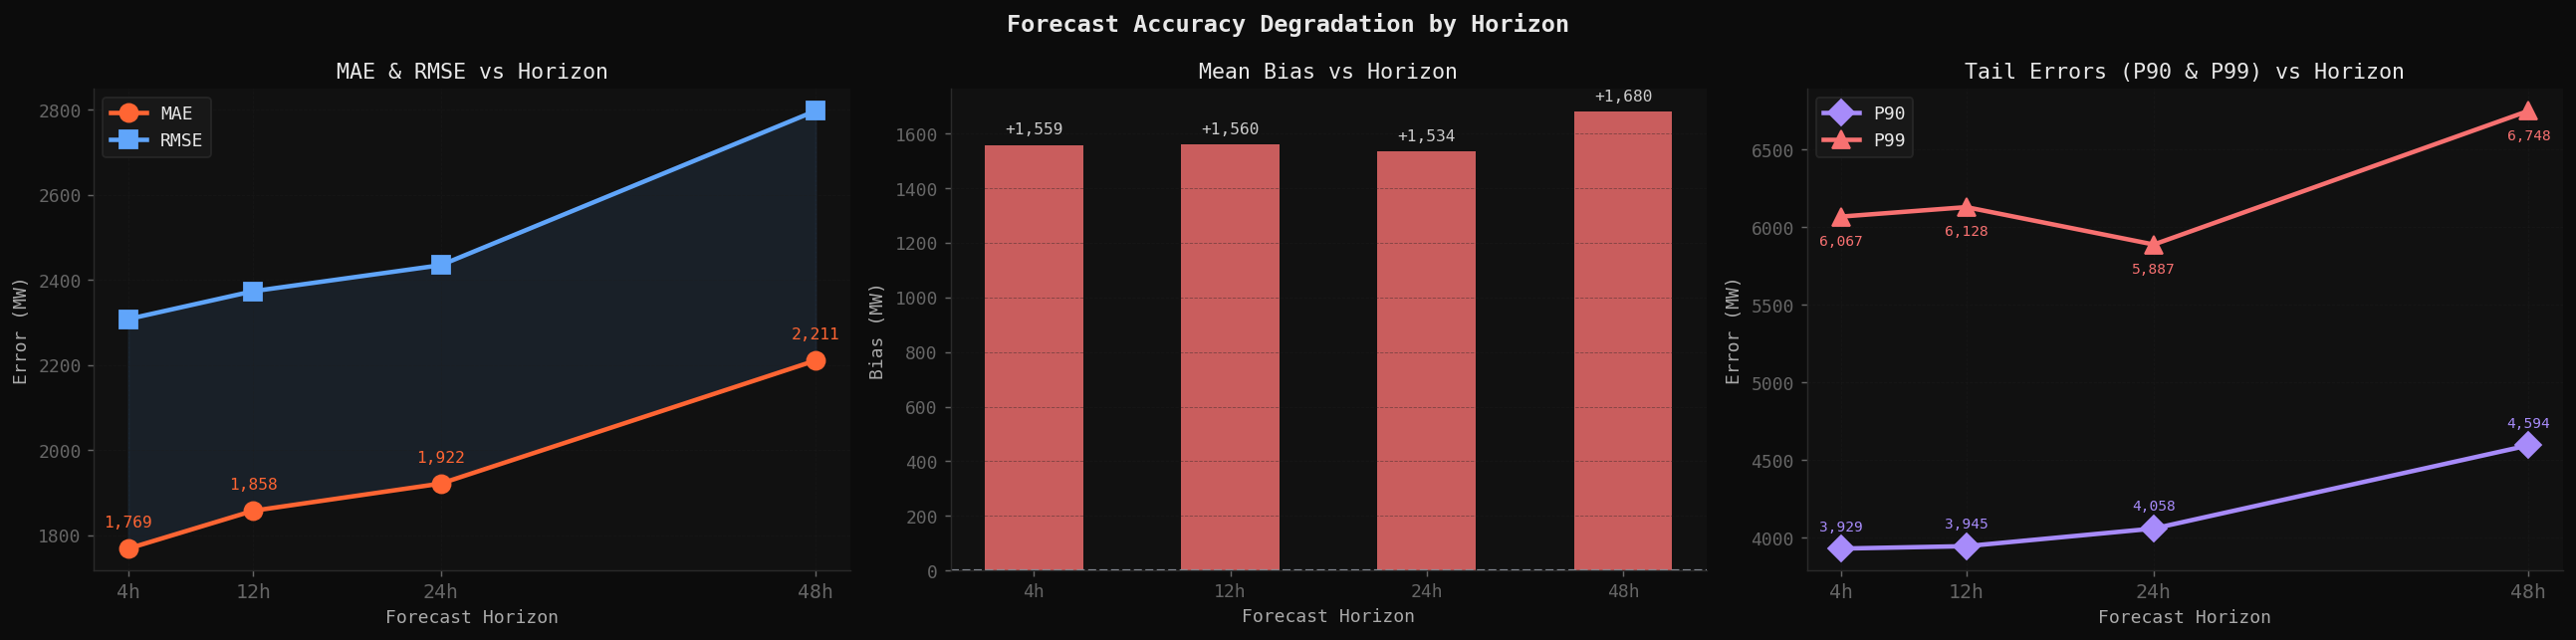

In [31]:
# ── Per-horizon statistics ────────────────────────────────────
hz_stats = df_horizon.groupby('horizonHours').agg(
    mae   = ('abs_error', 'mean'),
    rmse  = ('abs_error', lambda x: np.sqrt((x**2).mean())),
    bias  = ('error',     'mean'),
    p90   = ('abs_error', lambda x: np.nanpercentile(x, 90)),
    p99   = ('abs_error', lambda x: np.nanpercentile(x, 99)),
    count = ('abs_error', 'count')
).reset_index()

# ── Print full table ──────────────────────────────────────────
print('=' * 72)
print('  HORIZON DEGRADATION TABLE')
print('=' * 72)
print(f'  {"Horizon":>8}  {"MAE (MW)":>10}  {"RMSE (MW)":>10}  {"Bias (MW)":>10}  {"P90 (MW)":>10}  {"P99 (MW)":>10}')
print('-' * 72)
for _, row in hz_stats.iterrows():
    print(f'  {int(row["horizonHours"]):>6}h  '
          f'{row["mae"]:>10,.0f}  '
          f'{row["rmse"]:>10,.0f}  '
          f'{row["bias"]:>+10,.0f}  '
          f'{row["p90"]:>10,.0f}  '
          f'{row["p99"]:>10,.0f}')
print('=' * 72)

# ── Key degradation metrics ───────────────────────────────────
base_mae  = hz_stats.loc[hz_stats['horizonHours']==4,  'mae'].values[0]
mae_12    = hz_stats.loc[hz_stats['horizonHours']==12, 'mae'].values[0]
mae_24    = hz_stats.loc[hz_stats['horizonHours']==24, 'mae'].values[0]
mae_48    = hz_stats.loc[hz_stats['horizonHours']==48, 'mae'].values[0]

print()
print('  DEGRADATION vs 4h BASELINE')
print('-' * 72)
print(f'  4h  MAE : {base_mae:,.0f} MW  (baseline)')
print(f'  12h MAE : {mae_12:,.0f} MW  ({(mae_12-base_mae)/base_mae*100:+.1f}% vs 4h)')
print(f'  24h MAE : {mae_24:,.0f} MW  ({(mae_24-base_mae)/base_mae*100:+.1f}% vs 4h)')
print(f'  48h MAE : {mae_48:,.0f} MW  ({(mae_48-base_mae)/base_mae*100:+.1f}% vs 4h)')
print(f'\n  4h → 48h total degradation : {(mae_48-base_mae)/base_mae*100:+.1f}%')
print(f'  48h MAE is {mae_48/base_mae:.2f}x the 4h MAE')
print('=' * 72)

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Forecast Accuracy Degradation by Horizon', fontsize=13, fontweight='bold', color='#E8E8E8')

horizons = hz_stats['horizonHours'].values

# MAE & RMSE
ax = axes[0]
ax.plot(horizons, hz_stats['mae'],  color=ORANGE, linewidth=2.5, marker='o', markersize=10, label='MAE',  zorder=3)
ax.plot(horizons, hz_stats['rmse'], color=BLUE,   linewidth=2.5, marker='s', markersize=10, label='RMSE', zorder=3)
ax.fill_between(horizons, hz_stats['mae'], hz_stats['rmse'], alpha=0.1, color=BLUE)
for h, m in zip(horizons, hz_stats['mae']):
    ax.annotate(f'{m:,.0f}', (h, m), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9, color=ORANGE)
ax.set_xticks(horizons)
ax.set_xticklabels([f'{int(h)}h' for h in horizons], fontsize=11)
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Error (MW)')
ax.set_title('MAE & RMSE vs Horizon', color='#E8E8E8')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

# Bias
ax2 = axes[1]
bar_colors = [RED if v > 0 else BLUE for v in hz_stats['bias']]
bars = ax2.bar([f'{int(h)}h' for h in horizons], hz_stats['bias'],
               color=bar_colors, alpha=0.8, width=0.5)
for bar, val in zip(bars, hz_stats['bias']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:+,.0f}', ha='center', va='bottom', fontsize=9, color='#CCCCCC')
ax2.axhline(0, color=GREY, linewidth=1.2, linestyle='--')
ax2.set_xlabel('Forecast Horizon')
ax2.set_ylabel('Bias (MW)')
ax2.set_title('Mean Bias vs Horizon', color='#E8E8E8')
ax2.grid(True, axis='y', alpha=0.4)

# P90 & P99
ax3 = axes[2]
ax3.plot(horizons, hz_stats['p90'], color=PURPLE, linewidth=2.5, marker='D', markersize=10, label='P90')
ax3.plot(horizons, hz_stats['p99'], color=RED,    linewidth=2.5, marker='^', markersize=10, label='P99')
for h, p9, p99 in zip(horizons, hz_stats['p90'], hz_stats['p99']):
    ax3.annotate(f'{p9:,.0f}',  (h, p9),  textcoords='offset points', xytext=(0, 10),  ha='center', fontsize=8, color=PURPLE)
    ax3.annotate(f'{p99:,.0f}', (h, p99), textcoords='offset points', xytext=(0, -16), ha='center', fontsize=8, color=RED)
ax3.set_xticks(horizons)
ax3.set_xticklabels([f'{int(h)}h' for h in horizons], fontsize=11)
ax3.set_xlabel('Forecast Horizon')
ax3.set_ylabel('Error (MW)')
ax3.set_title('Tail Errors (P90 & P99) vs Horizon', color='#E8E8E8')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('horizon_degradation.png', bbox_inches='tight', facecolor='#0C0C0C')
plt.show()


## 2. Overall Error Statistics
A single-number summary of model accuracy. RMSE is more sensitive to large errors than MAE — a large gap between RMSE and MAE indicates the presence of occasional severe forecast failures.

In [32]:
n    = len(df)
rmse = np.sqrt((df['error']**2).mean())
mae  = df['abs_error'].mean()
bias = df['error'].mean()
med  = df['error'].median()
p50  = np.percentile(df['abs_error'], 50)
p75  = np.percentile(df['abs_error'], 75)
p90  = np.percentile(df['abs_error'], 90)
p95  = np.percentile(df['abs_error'], 95)
p99  = np.percentile(df['abs_error'], 99)
corr = df['actual_MW'].corr(df['forecast_MW'])
mape = (df['abs_error'] / df['actual_MW'] * 100).mean()

metrics = {
    'Records':               f'{n:,}',
    'RMSE':                  f'{rmse:,.0f} MW',
    'MAE':                   f'{mae:,.0f} MW',
    'MAPE':                  f'{mape:.1f}%',
    'Bias (mean error)':     f'{bias:+,.0f} MW  → {"OVER-forecasting" if bias > 0 else "UNDER-forecasting"}',
    'Median error':          f'{med:+,.0f} MW',
    'P50 |error|':           f'{p50:,.0f} MW',
    'P75 |error|':           f'{p75:,.0f} MW',
    'P90 |error|':           f'{p90:,.0f} MW',
    'P95 |error|':           f'{p95:,.0f} MW',
    'P99 |error|':           f'{p99:,.0f} MW',
    'Pearson r':             f'{corr:.4f}',
}

print('=' * 52)
print('  SUMMARY STATISTICS')
print('=' * 52)
for k, v in metrics.items():
    print(f'  {k:<25}: {v}')
print('=' * 52)
print(f'\n  RMSE / MAE ratio: {rmse/mae:.2f}  (>1.3 suggests occasional large spikes)')

  SUMMARY STATISTICS
  Records                  : 7,970
  RMSE                     : 2,289 MW
  MAE                      : 1,753 MW
  MAPE                     : inf%
  Bias (mean error)        : +1,549 MW  → OVER-forecasting
  Median error             : +1,306 MW
  P50 |error|              : 1,366 MW
  P75 |error|              : 2,605 MW
  P90 |error|              : 3,904 MW
  P95 |error|              : 4,655 MW
  P99 |error|              : 6,081 MW
  Pearson r                : 0.9551

  RMSE / MAE ratio: 1.31  (>1.3 suggests occasional large spikes)


## 3. Error Distribution

The histogram shows the full shape of the error distribution. Key things to look for:
- **Symmetric vs skewed** — a rightward skew means the model occasionally under-forecasts by large amounts
- **Bias** — if the mean is non-zero, the model has a systematic directional tendency
- **Q-Q plot** — deviations from the diagonal at the extremes indicate heavier tails than a Gaussian, meaning large errors occur more frequently than a normal distribution would predict

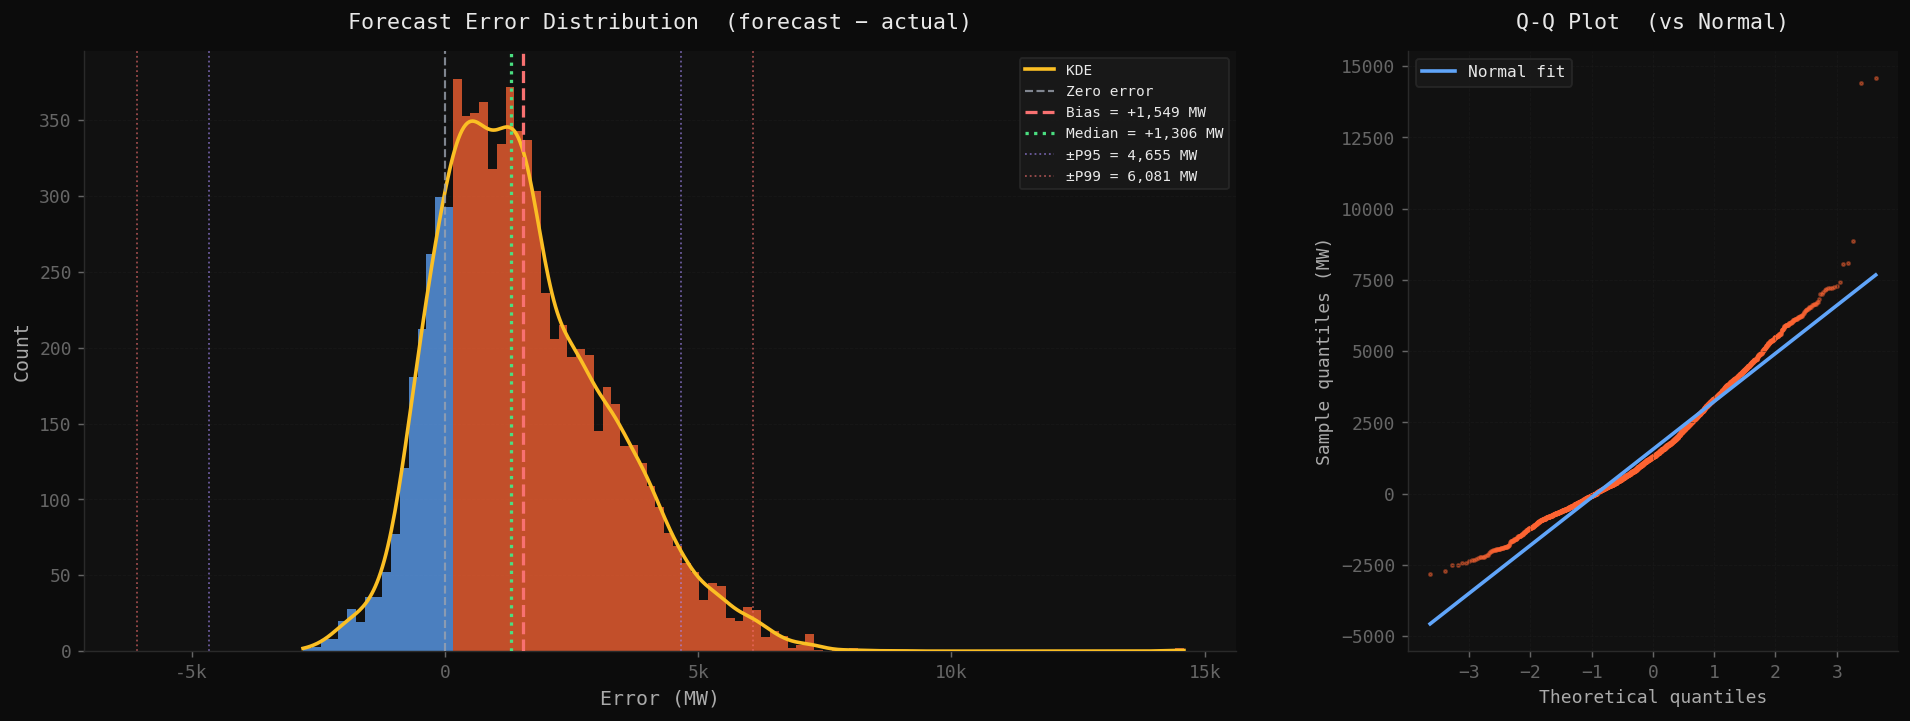

Skewness : 0.707  (0 = symmetric)
Kurtosis : 0.948  (0 = normal tails, >0 = heavier tails)


In [33]:
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Histogram ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_title('Forecast Error Distribution  (forecast − actual)', fontsize=12, pad=12)

n_bins = min(100, n // 8)
counts, edges, patches = ax1.hist(
    df['error'], bins=n_bins, color=ORANGE, alpha=0.7, edgecolor='none', zorder=2
)

# Colour bars by sign
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor(BLUE if left < 0 else ORANGE)
    patch.set_alpha(0.75)

# KDE overlay
kde_x  = np.linspace(df['error'].min(), df['error'].max(), 500)
kde    = gaussian_kde(df['error'].dropna())
kde_y  = kde(kde_x) * n * (edges[1] - edges[0])
ax1.plot(kde_x, kde_y, color=YELLOW, linewidth=2, label='KDE', zorder=3)

ax1.axvline(0,    color=GREY, linewidth=1.2, linestyle='--', alpha=0.8, label='Zero error', zorder=4)
ax1.axvline(bias, color=RED,  linewidth=1.8, linestyle='--', label=f'Bias = {bias:+,.0f} MW', zorder=4)
ax1.axvline(med,  color=GREEN,linewidth=1.8, linestyle=':',  label=f'Median = {med:+,.0f} MW', zorder=4)

ax1.set_xlabel('Error (MW)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, axis='y', alpha=0.5)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if abs(x)>=1000 else str(int(x))))

# Percentile annotations
for pct, val, color in [(95, p95, PURPLE), (99, p99, RED)]:
    ax1.axvline( val, color=color, linewidth=1, linestyle=':', alpha=0.6)
    ax1.axvline(-val, color=color, linewidth=1, linestyle=':', alpha=0.6,
                label=f'±P{pct} = {val:,.0f} MW')
ax1.legend(fontsize=8)

# ── Q-Q Plot ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_title('Q-Q Plot  (vs Normal)', fontsize=12, pad=12)

sample_qq = df['error'].dropna().sample(min(5000, len(df)), random_state=42)
osm, osr  = stats.probplot(sample_qq, dist='norm')
ax2.scatter(osm[0], osm[1], s=3, color=ORANGE, alpha=0.4, rasterized=True)
slope, intercept = np.polyfit(osm[0], osm[1], 1)
x_line = np.array([osm[0][0], osm[0][-1]])
ax2.plot(x_line, slope * x_line + intercept, color=BLUE, linewidth=2, label='Normal fit')
ax2.set_xlabel('Theoretical quantiles', fontsize=10)
ax2.set_ylabel('Sample quantiles (MW)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.5)

fig.suptitle('', fontsize=1)
plt.savefig('error_distribution.png', bbox_inches='tight', facecolor='#0C0C0C')
plt.show()

print(f'Skewness : {df["error"].skew():.3f}  (0 = symmetric)')
print(f'Kurtosis : {df["error"].kurtosis():.3f}  (0 = normal tails, >0 = heavier tails)')


## 4. Error vs Forecast Horizon

A fundamental property of any forecast model is that accuracy degrades as the lead time (horizon) increases. We bin errors by horizon hour and compute MAE and RMSE for each bin to quantify this degradation rate.

**Interpretation guide:**
- A steep slope = model accuracy degrades rapidly with lead time
- A flat slope = the model has similar accuracy regardless of how far ahead it is forecasting
- A non-monotonic curve = the model may be re-calibrated at certain horizons


  HORIZON ANALYSIS — FULL TABLE
  Horizon Bin     MAE (MW)   RMSE (MW)   Bias (MW)   Count
-----------------------------------------------------------------
  2–4h               1,694       2,246      +1,487    1327   ↑ OVER
  4–6h               1,723       2,253      +1,517    4817   ↑ OVER
  6–8h               1,874       2,411      +1,679    1826   ↑ OVER

  KEY FINDINGS
-----------------------------------------------------------------
  MAE at shortest horizon (2–4h)  : 1,694 MW
  MAE at longest  horizon (6–8h) : 1,874 MW
  Degradation                                  : +10.6%
  Worst horizon bin (highest MAE)              : 6–8h  →  1,874 MW
  Best  horizon bin (lowest  MAE)              : 2–4h  →  1,694 MW
  Worst/Best MAE ratio                         : 1.11x
  Max over-forecast bias at                    : 6–8h  →  +1,679 MW
  Max under-forecast bias at                   : 2–4h  →  1,487 MW
  horizonHours range in data                   : 4.0h  →  8.0h
  Total rows with horizon

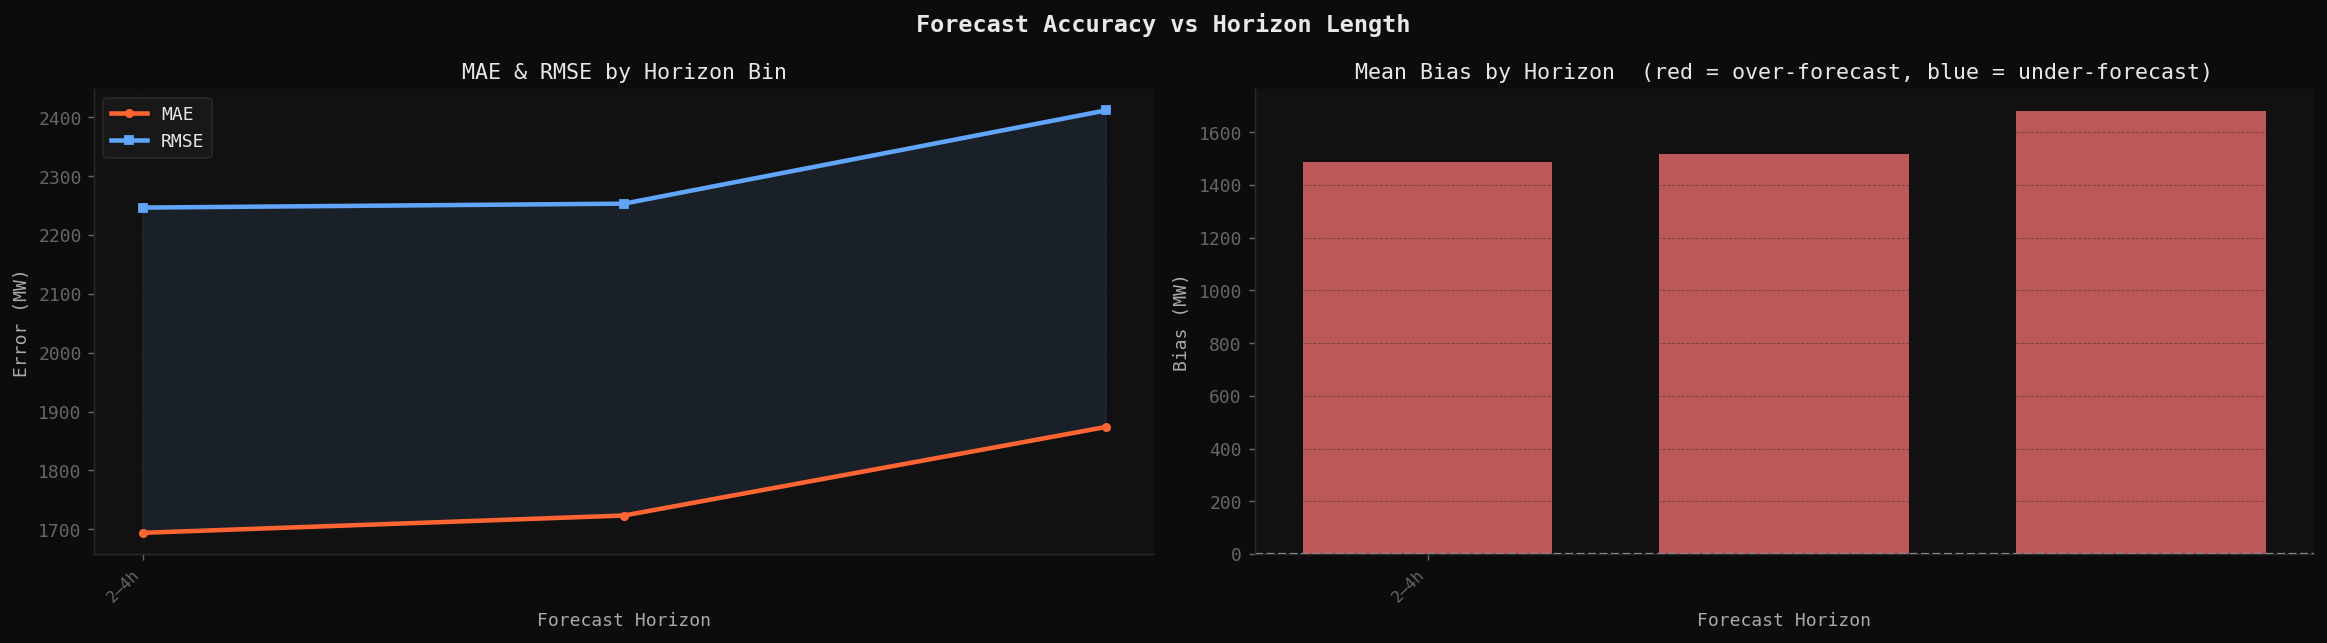

In [34]:
if 'horizonHours' in df.columns and df['horizonHours'].notna().sum() > 100:
    df_h = df.dropna(subset=['horizonHours']).copy()
    df_h['horizon_bin'] = pd.cut(
        df_h['horizonHours'],
        bins=list(range(0, 50, 2)),
        labels=[f'{i}–{i+2}h' for i in range(0, 48, 2)]
    )

    hbin = df_h.groupby('horizon_bin', observed=True).agg(
        mae   = ('abs_error', 'mean'),
        rmse  = ('abs_error', lambda x: np.sqrt((x**2).mean())),
        bias  = ('error',     'mean'),
        count = ('abs_error', 'count')
    ).reset_index()
    hbin = hbin[hbin['count'] >= 10]

    # ── Print full table ──────────────────────────────────
    print('=' * 65)
    print('  HORIZON ANALYSIS — FULL TABLE')
    print('=' * 65)
    print(f'  {"Horizon Bin":<12}  {"MAE (MW)":>10}  {"RMSE (MW)":>10}  {"Bias (MW)":>10}  {"Count":>6}')
    print('-' * 65)
    for _, row in hbin.iterrows():
        direction = '↑ OVER' if row['bias'] > 0 else '↓ UNDER'
        print(f'  {str(row["horizon_bin"]):<12}  {row["mae"]:>10,.0f}  {row["rmse"]:>10,.0f}  {row["bias"]:>+10,.0f}  {int(row["count"]):>6}   {direction}')
    print('=' * 65)

    # ── Key summary numbers ───────────────────────────────
    first_mae  = hbin['mae'].iloc[0]
    last_mae   = hbin['mae'].iloc[-1]
    pct_deg    = (last_mae - first_mae) / first_mae * 100
    worst_bin  = hbin.loc[hbin['mae'].idxmax(), 'horizon_bin']
    worst_mae  = hbin['mae'].max()
    best_bin   = hbin.loc[hbin['mae'].idxmin(), 'horizon_bin']
    best_mae   = hbin['mae'].min()
    max_bias   = hbin['bias'].max()
    max_bias_b = hbin.loc[hbin['bias'].idxmax(), 'horizon_bin']
    min_bias   = hbin['bias'].min()
    min_bias_b = hbin.loc[hbin['bias'].idxmin(), 'horizon_bin']

    print()
    print('  KEY FINDINGS')
    print('-' * 65)
    print(f'  MAE at shortest horizon ({hbin["horizon_bin"].iloc[0]})  : {first_mae:,.0f} MW')
    print(f'  MAE at longest  horizon ({hbin["horizon_bin"].iloc[-1]}) : {last_mae:,.0f} MW')
    print(f'  Degradation                                  : {pct_deg:+.1f}%')
    print(f'  Worst horizon bin (highest MAE)              : {worst_bin}  →  {worst_mae:,.0f} MW')
    print(f'  Best  horizon bin (lowest  MAE)              : {best_bin}  →  {best_mae:,.0f} MW')
    print(f'  Worst/Best MAE ratio                         : {worst_mae/best_mae:.2f}x')
    print(f'  Max over-forecast bias at                    : {max_bias_b}  →  +{max_bias:,.0f} MW')
    print(f'  Max under-forecast bias at                   : {min_bias_b}  →  {min_bias:,.0f} MW')
    print(f'  horizonHours range in data                   : {df_h["horizonHours"].min():.1f}h  →  {df_h["horizonHours"].max():.1f}h')
    print(f'  Total rows with horizon data                 : {len(df_h):,}')
    print('=' * 65)

    # ── Graphs ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('Forecast Accuracy vs Horizon Length', fontsize=13, fontweight='bold', color='#E8E8E8')

    ax = axes[0]
    x  = range(len(hbin))
    ax.plot(x, hbin['mae'],  color=ORANGE, linewidth=2.5, marker='o', markersize=4, label='MAE')
    ax.plot(x, hbin['rmse'], color=BLUE,   linewidth=2.5, marker='s', markersize=4, label='RMSE')
    ax.fill_between(x, hbin['mae'], hbin['rmse'], alpha=0.1, color=BLUE)
    ax.set_xticks(list(x)[::3])
    ax.set_xticklabels(hbin['horizon_bin'].iloc[::3], rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Forecast Horizon')
    ax.set_ylabel('Error (MW)')
    ax.set_title('MAE & RMSE by Horizon Bin', color='#E8E8E8')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.4)

    ax2 = axes[1]
    colors_bias = [RED if v > 0 else BLUE for v in hbin['bias']]
    ax2.bar(x, hbin['bias'], color=colors_bias, alpha=0.75, width=0.7)
    ax2.axhline(0, color=GREY, linewidth=1.2, linestyle='--')
    ax2.set_xticks(list(x)[::3])
    ax2.set_xticklabels(hbin['horizon_bin'].iloc[::3], rotation=45, ha='right', fontsize=9)
    ax2.set_xlabel('Forecast Horizon')
    ax2.set_ylabel('Bias (MW)')
    ax2.set_title('Mean Bias by Horizon  (red = over-forecast, blue = under-forecast)', color='#E8E8E8')
    ax2.grid(True, axis='y', alpha=0.4)

    plt.tight_layout()
    plt.savefig('error_vs_horizon.png', bbox_inches='tight', facecolor='#0C0C0C')
    plt.show()

else:
    print('horizonHours column not available — skipping horizon analysis.')
    print('Export the CSV with the horizonHours column enabled in the dashboard.')


## 5. Error by Time of Day

Wind generation follows a diurnal cycle influenced by atmospheric heating patterns. The forecast model may be systematically less accurate at certain hours — particularly during morning and evening ramp periods when generation is changing rapidly.

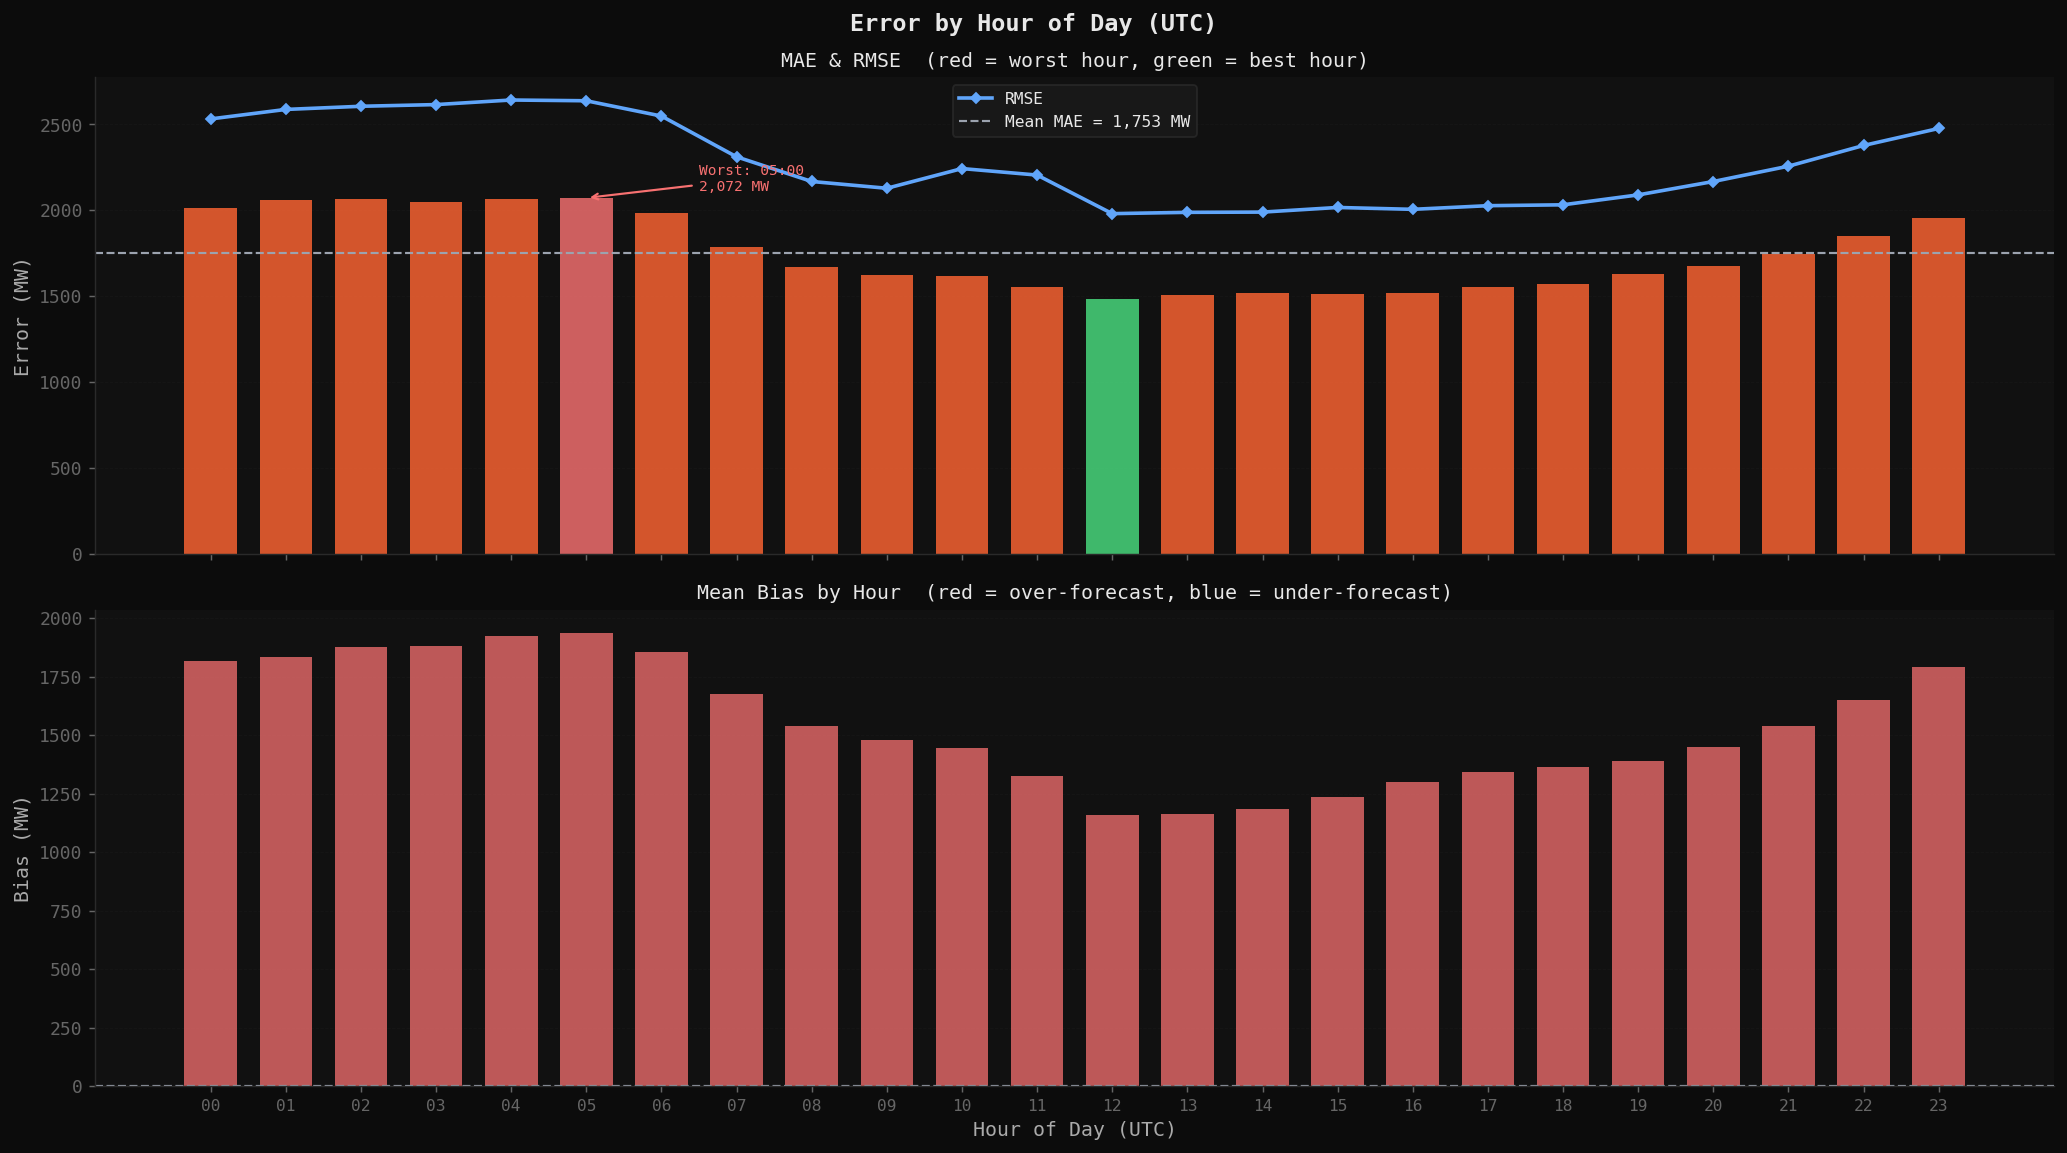

Worst hour : 05:00 UTC  (MAE = 2,072 MW)
Best  hour : 12:00 UTC  (MAE = 1,483 MW)
Ratio worst/best : 1.40x


In [35]:
hourly_mae  = df.groupby('hour')['abs_error'].mean()
hourly_bias = df.groupby('hour')['error'].mean()
hourly_rmse = df.groupby('hour')['error'].apply(lambda x: np.sqrt((x**2).mean()))

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Error by Hour of Day (UTC)', fontsize=13, fontweight='bold', color='#E8E8E8')

# MAE by hour
ax = axes[0]
worst_h = hourly_mae.idxmax()
best_h  = hourly_mae.idxmin()
bar_colors = [RED if h == worst_h else (GREEN if h == best_h else ORANGE) for h in hourly_mae.index]
bars = ax.bar(hourly_mae.index, hourly_mae.values, color=bar_colors, alpha=0.82, width=0.7, zorder=2)
ax.plot(hourly_mae.index, hourly_rmse.values, color=BLUE, linewidth=2,
        marker='D', markersize=4, label='RMSE', zorder=3)
ax.axhline(hourly_mae.mean(), color=GREY, linewidth=1.2, linestyle='--',
           label=f'Mean MAE = {hourly_mae.mean():,.0f} MW')
ax.set_ylabel('Error (MW)', fontsize=11)
ax.set_title('MAE & RMSE  (red = worst hour, green = best hour)', color='#E8E8E8', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.4)
ax.annotate(f'Worst: {worst_h:02d}:00\n{hourly_mae[worst_h]:,.0f} MW',
            xy=(worst_h, hourly_mae[worst_h]),
            xytext=(worst_h + 1.5, hourly_mae[worst_h] * 1.02),
            fontsize=8, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

# Bias by hour
ax2 = axes[1]
bias_colors = [RED if v > 0 else BLUE for v in hourly_bias.values]
ax2.bar(hourly_bias.index, hourly_bias.values, color=bias_colors, alpha=0.75, width=0.7, zorder=2)
ax2.axhline(0, color=GREY, linewidth=1.2, linestyle='--')
ax2.set_xlabel('Hour of Day (UTC)', fontsize=11)
ax2.set_ylabel('Bias (MW)', fontsize=11)
ax2.set_title('Mean Bias by Hour  (red = over-forecast, blue = under-forecast)', color='#E8E8E8', fontsize=11)
ax2.set_xticks(range(0, 24))
ax2.set_xticklabels([f'{h:02d}' for h in range(0, 24)], fontsize=9)
ax2.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('error_by_hour.png', bbox_inches='tight', facecolor='#0C0C0C')
plt.show()

print(f'Worst hour : {worst_h:02d}:00 UTC  (MAE = {hourly_mae[worst_h]:,.0f} MW)')
print(f'Best  hour : {best_h:02d}:00 UTC  (MAE = {hourly_mae[best_h]:,.0f} MW)')
print(f'Ratio worst/best : {hourly_mae[worst_h]/hourly_mae[best_h]:.2f}x')


## 6. Error by Day of Week

Weekend and weekday wind patterns differ as atmospheric conditions are independent of human activity, but forecast model calibration may vary. We also compare weekday vs weekend aggregate statistics.


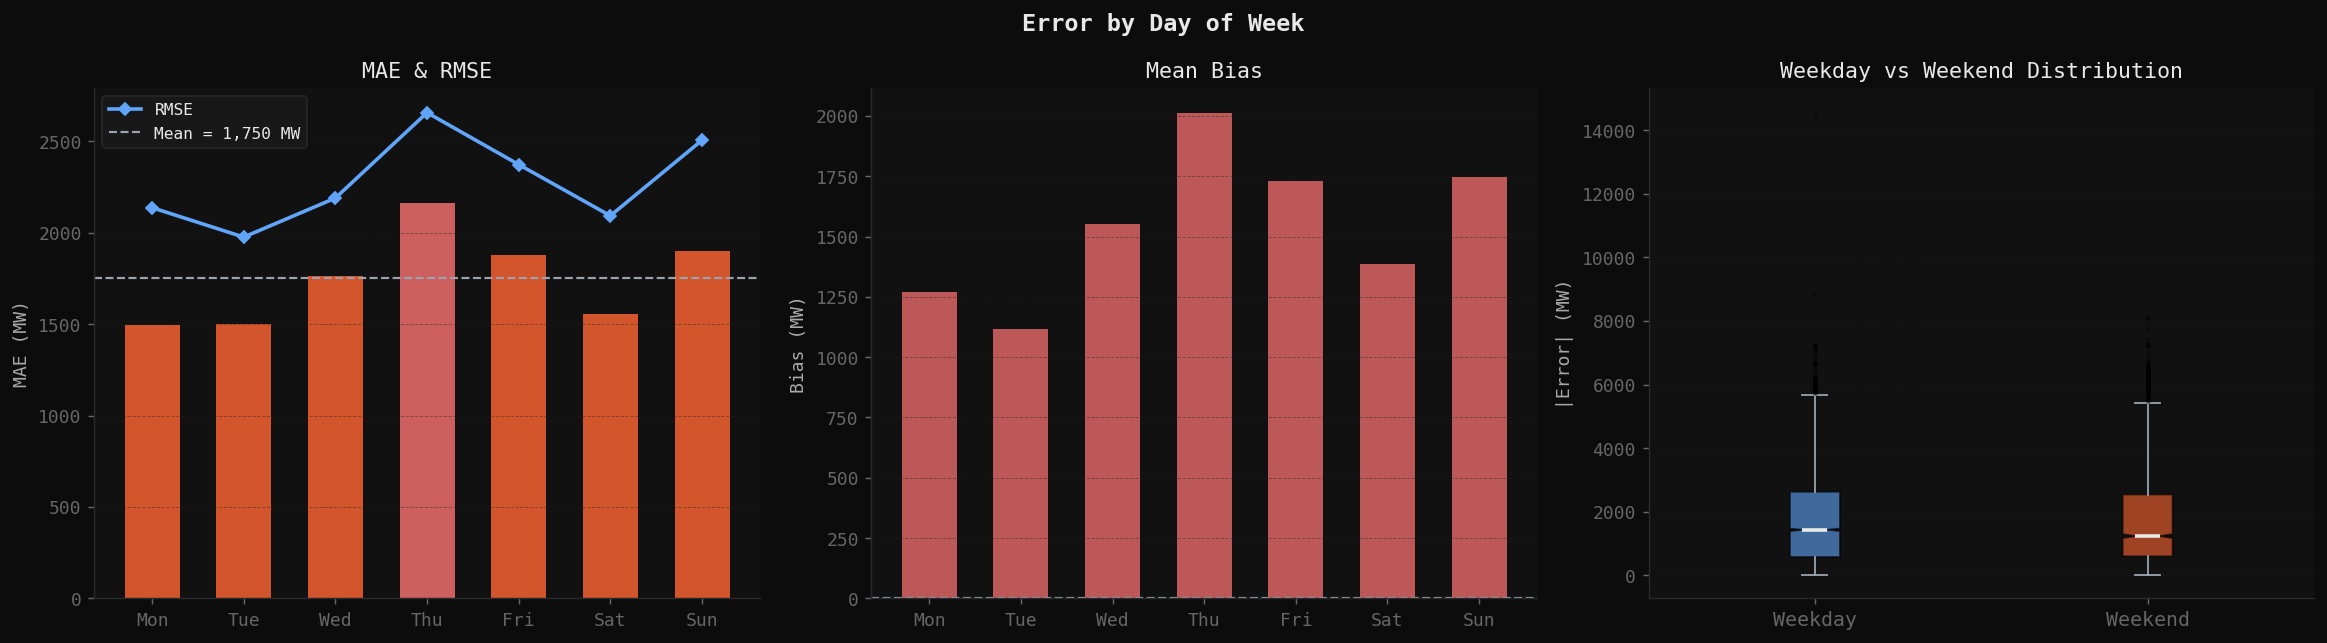

Weekday MAE  : 1,763 MW
Weekend MAE  : 1,728 MW
Difference   : -36 MW


In [36]:
dow_stats = df.groupby('dow_name').agg(
    mae   = ('abs_error', 'mean'),
    rmse  = ('abs_error', lambda x: np.sqrt((x**2).mean())),
    bias  = ('error',     'mean'),
    count = ('abs_error', 'count')
).reindex(DOW_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Error by Day of Week', fontsize=13, fontweight='bold', color='#E8E8E8')

# MAE
ax = axes[0]
worst_d = dow_stats['mae'].idxmax()
bar_c = [RED if d == worst_d else ORANGE for d in DOW_ORDER]
ax.bar(range(7), dow_stats['mae'], color=bar_c, alpha=0.82, width=0.6)
ax.plot(range(7), dow_stats['rmse'], color=BLUE, linewidth=2, marker='D', markersize=5, label='RMSE')
ax.axhline(dow_stats['mae'].mean(), color=GREY, linewidth=1.2, linestyle='--',
           label=f'Mean = {dow_stats["mae"].mean():,.0f} MW')
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in DOW_ORDER], fontsize=10)
ax.set_ylabel('MAE (MW)')
ax.set_title('MAE & RMSE', color='#E8E8E8')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.4)

# Bias
ax2 = axes[1]
b_colors = [RED if v > 0 else BLUE for v in dow_stats['bias']]
ax2.bar(range(7), dow_stats['bias'], color=b_colors, alpha=0.75, width=0.6)
ax2.axhline(0, color=GREY, linewidth=1.2, linestyle='--')
ax2.set_xticks(range(7))
ax2.set_xticklabels([d[:3] for d in DOW_ORDER], fontsize=10)
ax2.set_ylabel('Bias (MW)')
ax2.set_title('Mean Bias', color='#E8E8E8')
ax2.grid(True, axis='y', alpha=0.4)

# Weekday vs Weekend box
ax3 = axes[2]
wday = df[~df['is_weekend']]['abs_error']
wend = df[ df['is_weekend']]['abs_error']
bp = ax3.boxplot(
    [wday, wend],
    patch_artist=True,
    medianprops=dict(color='#E8E8E8', linewidth=2),
    whiskerprops=dict(color=GREY),
    capprops=dict(color=GREY),
    flierprops=dict(marker='.', color=ORANGE, alpha=0.3, markersize=3),
    notch=True
)
bp['boxes'][0].set_facecolor(BLUE)
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor(ORANGE)
bp['boxes'][1].set_alpha(0.6)
ax3.set_xticklabels(['Weekday', 'Weekend'], fontsize=11)
ax3.set_ylabel('|Error| (MW)')
ax3.set_title('Weekday vs Weekend Distribution', color='#E8E8E8')
ax3.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('error_by_dow.png', bbox_inches='tight', facecolor='#0C0C0C')
plt.show()

print(f'Weekday MAE  : {wday.mean():,.0f} MW')
print(f'Weekend MAE  : {wend.mean():,.0f} MW')
print(f'Difference   : {wend.mean()-wday.mean():+,.0f} MW')


## 7. Hour × Day Heatmap

A 2D heatmap reveals interaction effects between hour and day that individual analyses miss. If certain (hour, day) combinations are systematically worse, that indicates structured patterns in forecast failure the model could be improved on.


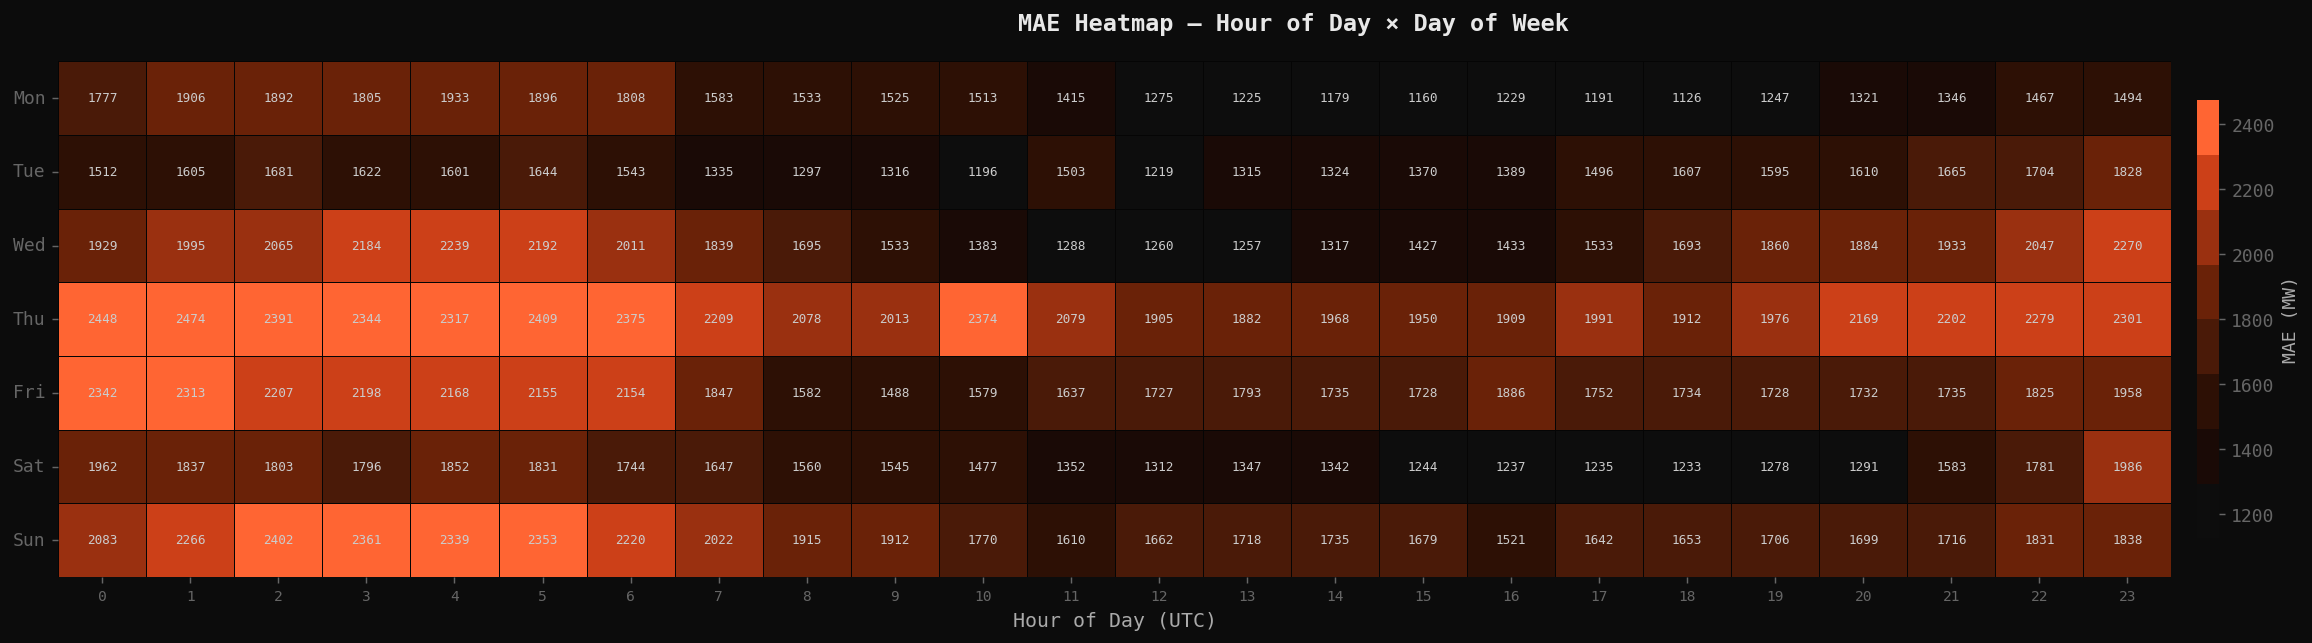

In [37]:
pivot = df.pivot_table(index='dow_name', columns='hour', values='abs_error', aggfunc='mean')
pivot = pivot.reindex(DOW_ORDER)

fig, ax = plt.subplots(figsize=(20, 5))
fig.suptitle('MAE Heatmap — Hour of Day × Day of Week', fontsize=13, fontweight='bold', color='#E8E8E8')

cmap = sns.color_palette([
    '#0d0d0d','#1a0a06','#2d1005','#4a1a08',
    '#6a2208','#9a3010','#cc4018','#FF6533',
], as_cmap=True)

sns.heatmap(
    pivot, ax=ax, cmap=cmap,
    linewidths=0.3, linecolor='#050505',
    cbar_kws={'label': 'MAE (MW)', 'shrink': 0.85, 'pad': 0.01},
    annot=True, fmt='.0f', annot_kws={'size': 7, 'color': '#CCCCCC'}
)

ax.set_xlabel('Hour of Day (UTC)', fontsize=11, color='#AAAAAA')
ax.set_ylabel('', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8)
ax.set_yticklabels([d[:3] for d in DOW_ORDER], rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('heatmap_hour_dow.png', bbox_inches='tight', facecolor='#0C0C0C')
plt.show()


## 8. Actual vs Forecast Scatter

A scatter plot of actual vs forecast values reveals systematic bias patterns. Points above the diagonal indicate under-forecasting (forecast < actual), points below indicate over-forecasting. A perfect model would have all points on the diagonal with Pearson r = 1.0.


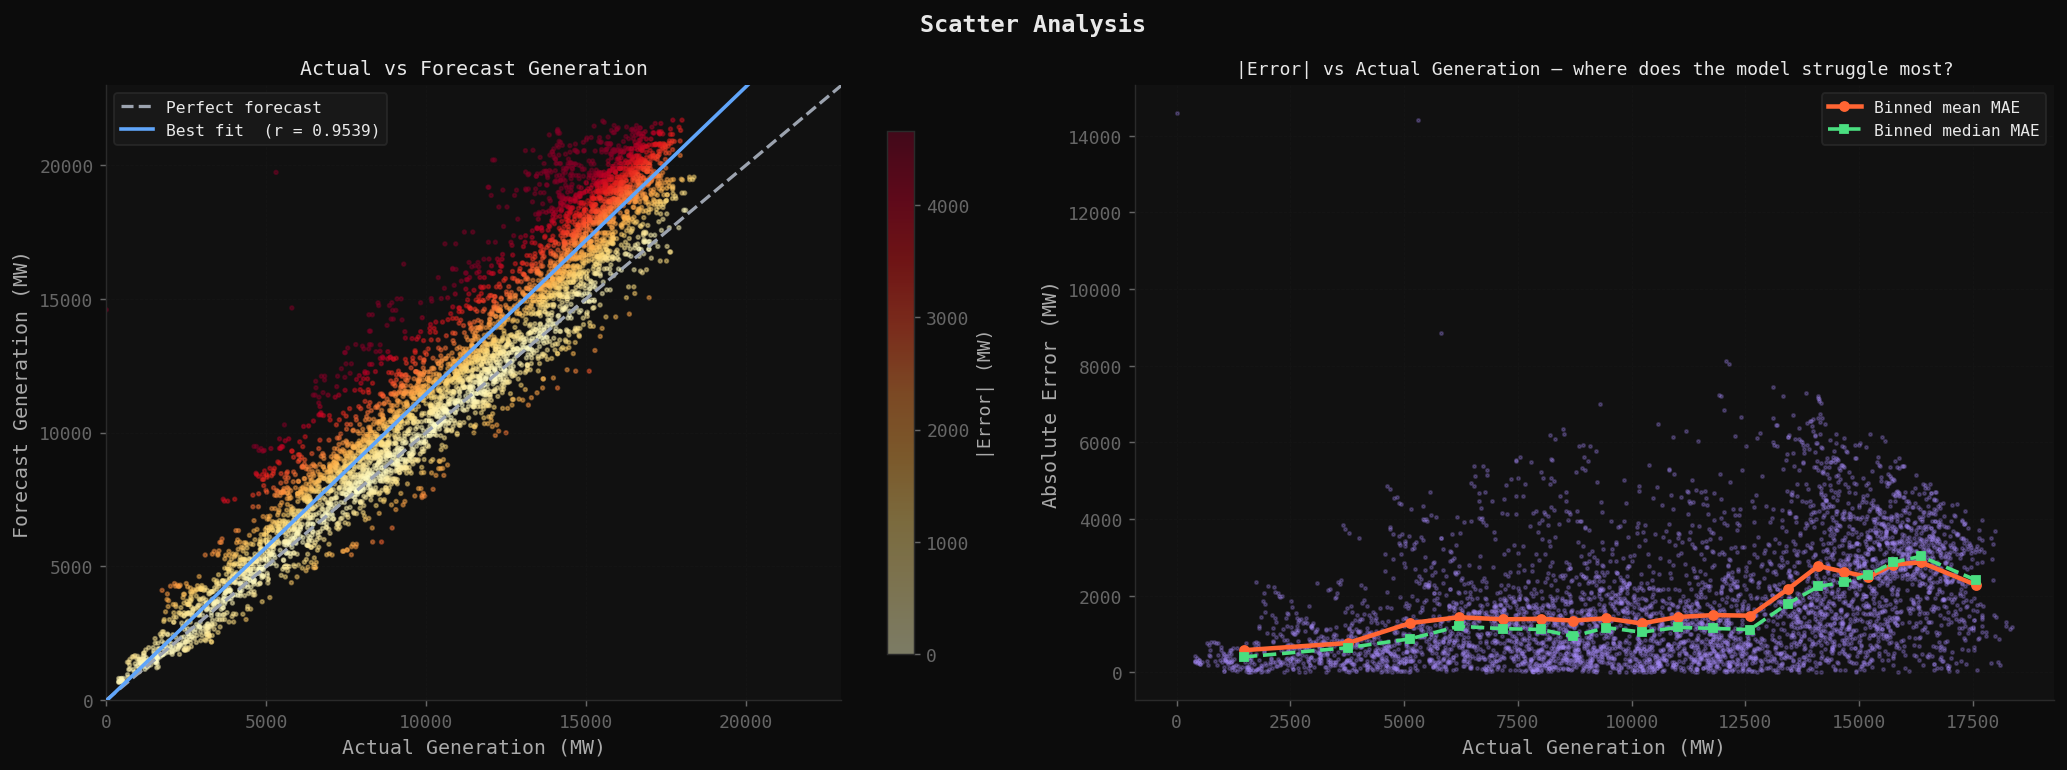

Linear fit slope : 1.1481  (1.0 = perfect)
Intercept        : -28 MW
Pearson r        : 0.9539


In [39]:
sample = df.sample(min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Scatter Analysis', fontsize=13, fontweight='bold', color='#E8E8E8')

# =========================
# Actual vs Forecast
# =========================
ax = axes[0]
ax.set_title('Actual vs Forecast Generation', color='#E8E8E8', fontsize=11)

sc = ax.scatter(sample['actual_MW'], sample['forecast_MW'],
                s=4, c=sample['abs_error'], cmap='YlOrRd',
                alpha=0.45, rasterized=True, vmin=0, vmax=p95)

plt.colorbar(sc, ax=ax, label='|Error| (MW)', shrink=0.85)

lim = max(df['actual_MW'].max(), df['forecast_MW'].max()) * 1.06

ax.plot([0, lim], [0, lim], color=GREY, linewidth=1.8,
        linestyle='--', label='Perfect forecast', zorder=5)

m, b_c, r_v, *_ = stats.linregress(sample['actual_MW'], sample['forecast_MW'])

xfit = np.linspace(0, lim, 200)

ax.plot(xfit, m * xfit + b_c, color=BLUE, linewidth=2,
        label=f'Best fit  (r = {r_v:.4f})', zorder=5)

ax.set_xlabel('Actual Generation (MW)', fontsize=11)
ax.set_ylabel('Forecast Generation (MW)', fontsize=11)

ax.legend(fontsize=9)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.grid(True, alpha=0.3)

# =========================
# Error vs Actual Magnitude
# =========================
ax2 = axes[1]
ax2.set_title('|Error| vs Actual Generation — where does the model struggle most?', 
              color='#E8E8E8', fontsize=10)

ax2.scatter(sample['actual_MW'], sample['abs_error'],
            s=3, color=PURPLE, alpha=0.25, rasterized=True)

bins   = np.percentile(df['actual_MW'], np.linspace(0, 100, 20))
bins   = np.unique(bins)

binned = pd.cut(df['actual_MW'], bins=bins)

grp = df.groupby(binned, observed=True)['abs_error'].agg(['mean','median'])

mids = [(i.left + i.right) / 2 for i in grp.index]

ax2.plot(mids, grp['mean'], color=ORANGE, linewidth=2.5,
         marker='o', markersize=5, label='Binned mean MAE')

ax2.plot(mids, grp['median'], color=GREEN, linewidth=2,
         marker='s', markersize=4, linestyle='--', label='Binned median MAE')

ax2.set_xlabel('Actual Generation (MW)', fontsize=11)
ax2.set_ylabel('Absolute Error (MW)', fontsize=11)

ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_analysis.png', bbox_inches='tight', facecolor='#0C0C0C')
plt.show()

print(f'Linear fit slope : {m:.4f}  (1.0 = perfect)')
print(f'Intercept        : {b_c:+,.0f} MW')
print(f'Pearson r        : {r_v:.4f}')

## 9. Error Trend Over Time

A rolling MAE over time reveals whether the model has systematic periods of degraded performance — potentially correlated with weather regimes, seasonal patterns, or data quality issues. A rising trend would warrant investigation.


In [41]:
print(df.columns)

Index(['startTime', 'actual_MW', 'forecast_MW', 'forecastPublishTime',
       'horizonHours', 'error', 'abs_error', 'hour', 'date', 'day_of_week',
       'dow_name', 'is_weekend'],
      dtype='object')


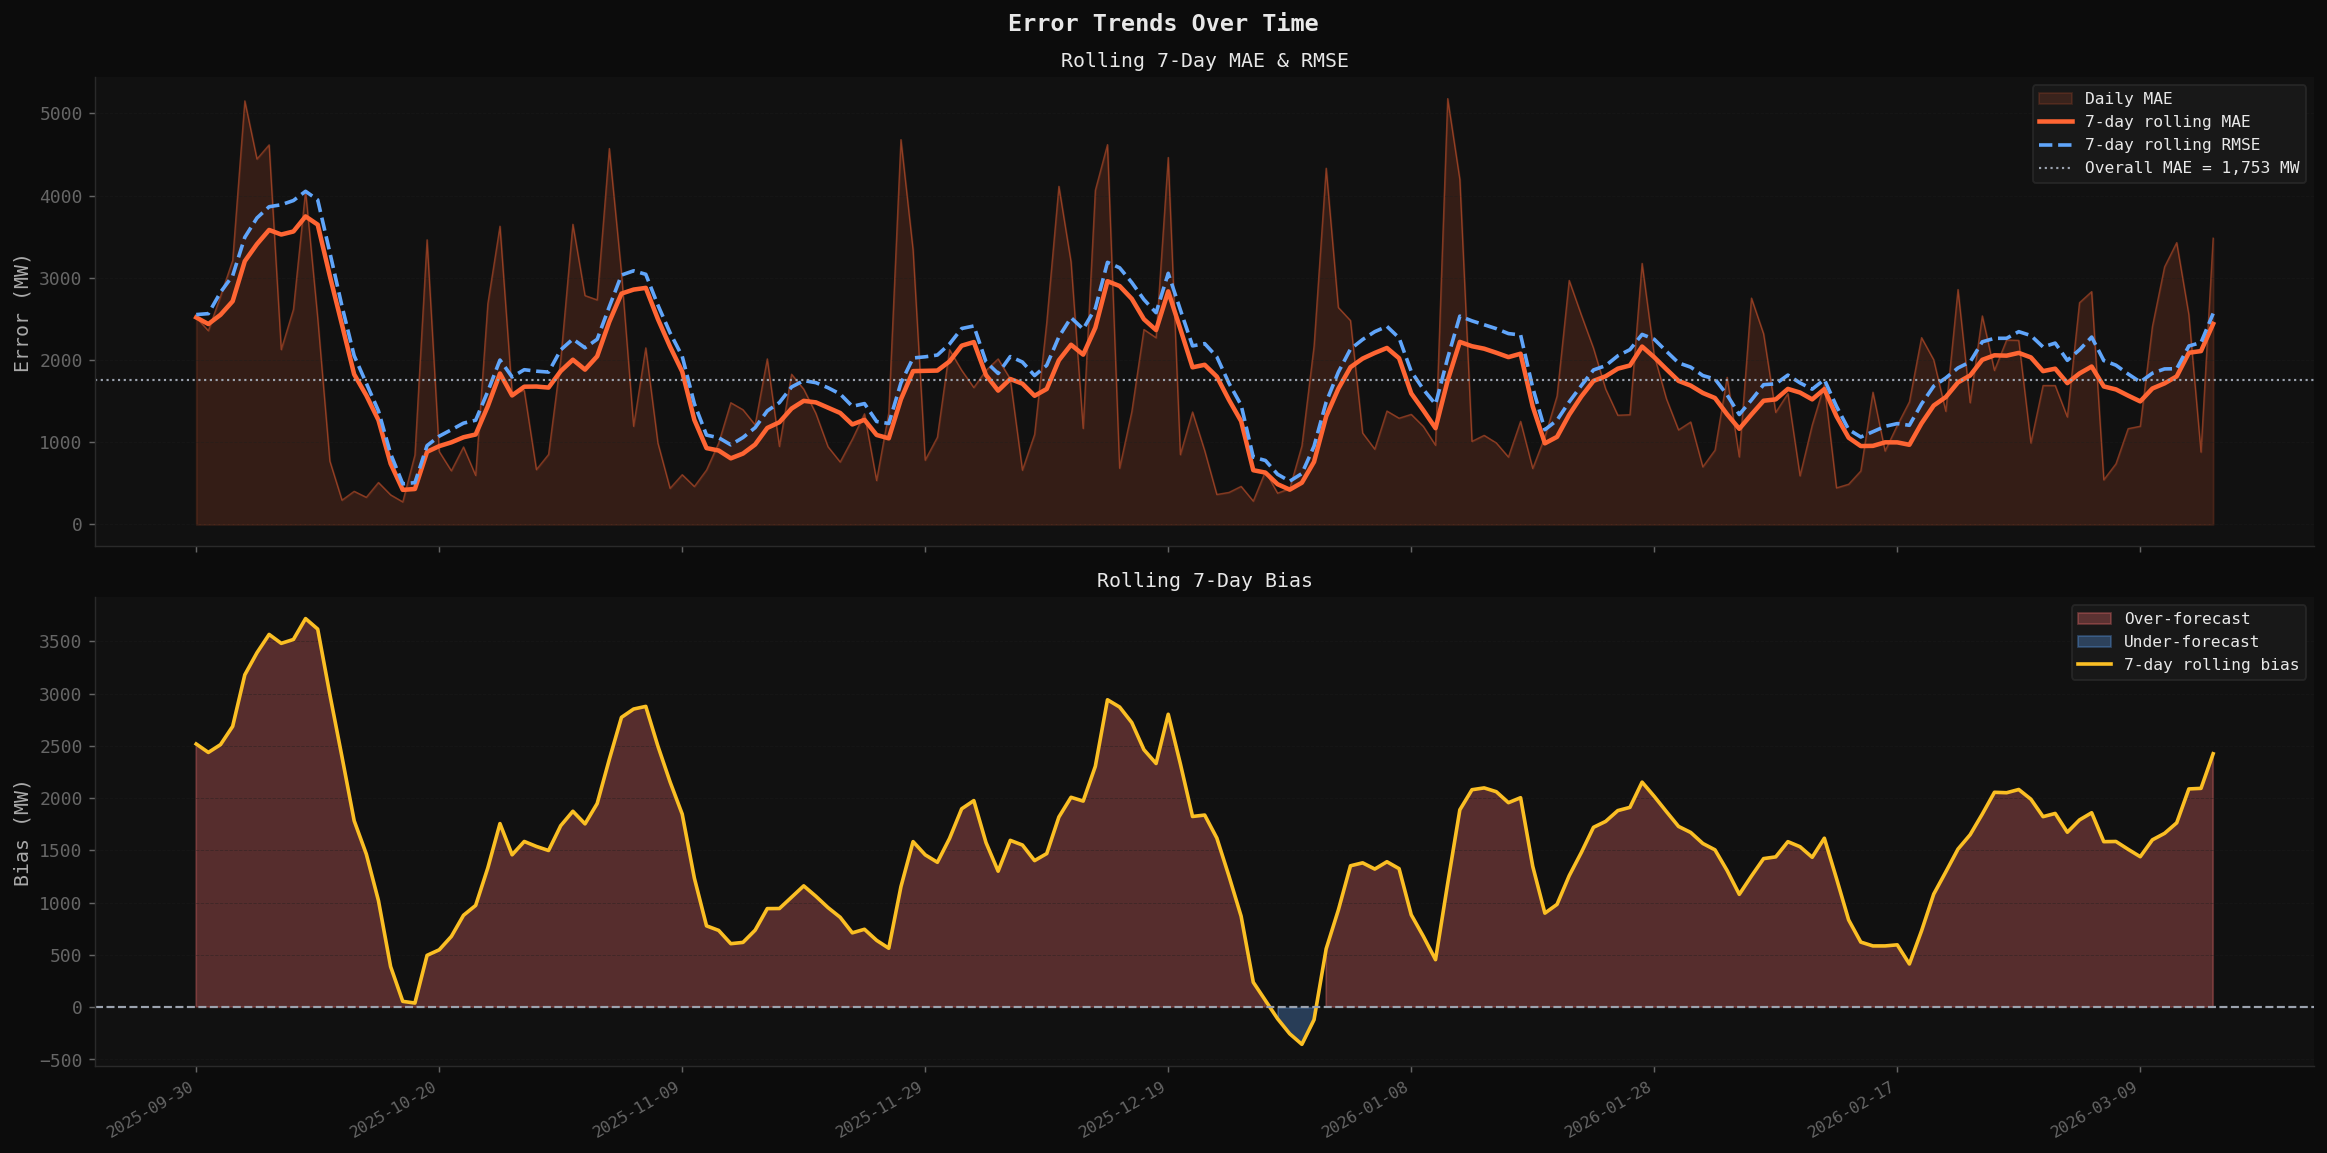

In [42]:
daily = df.groupby('date').agg(
    mae         = ('abs_error', 'mean'),
    rmse        = ('abs_error', lambda x: np.sqrt((x**2).mean())),
    bias        = ('error',     'mean'),
    avg_actual  = ('actual_MW', 'mean'), 
    count       = ('abs_error', 'count')
).reset_index().sort_values('date')

daily['rolling_mae']  = daily['mae'].rolling(7, min_periods=1).mean()
daily['rolling_rmse'] = daily['rmse'].rolling(7, min_periods=1).mean()
daily['rolling_bias'] = daily['bias'].rolling(7, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)
fig.suptitle('Error Trends Over Time', fontsize=13, fontweight='bold', color='#E8E8E8')

x     = range(len(daily))
ticks = list(range(0, len(daily), max(1, len(daily)//8)))

# MAE rolling
ax = axes[0]
ax.fill_between(x, daily['mae'], color=ORANGE, alpha=0.15, label='Daily MAE')
ax.plot(x, daily['mae'],          color=ORANGE, linewidth=0.8, alpha=0.4)
ax.plot(x, daily['rolling_mae'],  color=ORANGE, linewidth=2.5, label='7-day rolling MAE')
ax.plot(x, daily['rolling_rmse'], color=BLUE,   linewidth=2,
        linestyle='--', label='7-day rolling RMSE')
ax.axhline(mae, color=GREY, linewidth=1.2, linestyle=':', label=f'Overall MAE = {mae:,.0f} MW')
ax.set_ylabel('Error (MW)', fontsize=11)
ax.set_title('Rolling 7-Day MAE & RMSE', color='#E8E8E8', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.4)

# Bias rolling
ax2 = axes[1]
ax2.fill_between(x, daily['rolling_bias'],
                 where=[v > 0 for v in daily['rolling_bias']],
                 color=RED, alpha=0.3, label='Over-forecast')
ax2.fill_between(x, daily['rolling_bias'],
                 where=[v < 0 for v in daily['rolling_bias']],
                 color=BLUE, alpha=0.3, label='Under-forecast')
ax2.plot(x, daily['rolling_bias'], color=YELLOW, linewidth=2, label='7-day rolling bias')
ax2.axhline(0, color=GREY, linewidth=1.2, linestyle='--')
ax2.set_ylabel('Bias (MW)', fontsize=11)
ax2.set_title('Rolling 7-Day Bias', color='#E8E8E8', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, axis='y', alpha=0.4)

ax2.set_xticks(ticks)
ax2.set_xticklabels(
    [str(daily['date'].iloc[i]) for i in ticks],
    rotation=30, ha='right', fontsize=9
)

plt.tight_layout()
plt.savefig('error_trend.png', bbox_inches='tight', facecolor='#0C0C0C')
plt.show()


## 10. Conclusions & Key Findings

**Dataset:** 7,970 records · 30 September 2025 → March 2026 · ~170 days

---

### Overall Accuracy
- The model achieves an **MAE of 1,753 MW** and **RMSE of 2,289 MW**, indicating that on average the forecast deviates by ~**1.75 GW**, which is operationally significant for grid balancing.
- The **RMSE/MAE ratio of 1.31** confirms the presence of occasional large error spikes that inflate RMSE beyond typical error levels.
- The **Pearson correlation (r = 0.955)** shows strong trend tracking — the model captures direction well, but suffers from systematic offset rather than randomness.
- **MAPE is infinite**, indicating the presence of near-zero actual generation values — this metric is unreliable and should not be used for evaluation.

---

### Chronic Over-Forecasting Bias
- The model exhibits a strong **mean bias of +1,549 MW** and **median bias of +1,306 MW**, confirming persistent over-forecasting.
- This is a **structural issue**, not noise — forecasts are consistently ~1.5 GW higher than actual generation.
- The regression slope of **1.148** (vs ideal 1.0) confirms proportional over-prediction across the full range.

---

### Error Distribution Characteristics
- **Skewness = +0.707** → over-forecast errors dominate extreme cases.
- **Kurtosis = +0.948** → heavier-than-normal tails → large errors occur more frequently than Gaussian expectation.
- **P99 error = 6,081 MW (~3.47× MAE)** → rare but severe forecast failures exceeding 6 GW.

---

### Time-of-Day Effects
- Worst performance at **05:00 UTC** (MAE = 2,072 MW)
- Best performance at **12:00 UTC** (MAE = 1,483 MW)
- **Worst/Best ratio = 1.40×**, indicating a meaningful diurnal pattern.
- Early morning hours remain the most difficult due to atmospheric instability and wind ramp uncertainty.

---

### Weekday vs Weekend Effect
- **Weekday MAE = 1,763 MW**
- **Weekend MAE = 1,728 MW**
- Difference: **−36 MW (~2%)**

 Performance is effectively identical → no structural weekday bias.

---

### Forecast Horizon Degradation (Critical Insight)
- MAE increases from **1,769 MW (4h)** → **2,211 MW (48h)** → **+25.0% degradation**
- Degradation is **non-linear and back-loaded**:
  - 4h → 24h: modest increase (+8.6%)
  - 24h → 48h: sharp deterioration (+15% jump)
- Bias remains **stable across horizons (~+1.5–1.7 GW)** → confirms systemic model bias.
- Tail errors (P90/P99) increase with horizon, showing higher risk in long-term forecasts.

| Horizon | MAE | RMSE | Bias | P90 | P99 | vs 4h |
|--------|-----|------|------|-----|-----|------|
| 4h  | 1,769 | 2,308 | +1,559 | 3,929 | 6,067 | — |
| 12h | 1,858 | 2,374 | +1,560 | 3,945 | 6,128 | +5.0% |
| 24h | 1,922 | 2,435 | +1,534 | 4,058 | 5,887 | +8.6% |
| 48h | 2,211 | 2,798 | +1,680 | 4,594 | 6,748 | +25.0% |

---

### Priority Actions for Improvement
1. **Apply global bias correction (~+1,549 MW offset)** → immediate MAE reduction
2. **Introduce hour-specific correction** → especially 00:00–06:00 UTC window
3. **Investigate P99 events (>6 GW errors)** → identify storm-driven failures
4. **Add ML residual model (AR/temporal)** → strong autocorrelation suggests predictability in residuals